In [1]:
import numpy as np
from pyafv import FiniteVoronoiSimulator, PhysicalParams
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [2]:
def tile_pbc_with_index(pts: np.ndarray, r: float, L: float):
    """
    Periodic tiling of pts (N,2), with bookkeeping.
    Returns:
        pos_pbc  : (M,2) tiled positions
        idx_orig : (M,) indices mapping each tiled point back to original 0..N-1
    """
    pts = np.asarray(pts)
    N = pts.shape[0]
    thresh = 2.01 * r

    x = pts[:, 0]
    y = pts[:, 1]

    # --- Stage 1: originals + left/right ---
    mask_l = x <= thresh
    mask_r = x >= (L - thresh)
    inds_l = np.flatnonzero(mask_l)
    inds_r = np.flatnonzero(mask_r)
    n_l, n_r = inds_l.size, inds_r.size

    NA = N + n_l + n_r
    pos_aug = np.empty((NA, 2), dtype=pts.dtype)
    idx_aug = np.empty(NA, dtype=np.int64)

    # originals
    pos_aug[:N] = pts
    idx_aug[:N] = np.arange(N, dtype=np.int64)
    i = N

    # left (+L, 0)
    if n_l:
        sl = slice(i, i+n_l)
        pos_aug[sl] = pts[inds_l]
        pos_aug[sl, 0] += L
        idx_aug[sl] = inds_l
        i += n_l

    # right (−L, 0)
    if n_r:
        sl = slice(i, i+n_r)
        pos_aug[sl] = pts[inds_r]
        pos_aug[sl, 0] -= L
        idx_aug[sl] = inds_r
        i += n_r

    # --- Stage 2: on augmented, append down then up ---
    y_aug = pos_aug[:, 1]
    inds_d = np.flatnonzero(y_aug <= thresh)
    inds_u = np.flatnonzero(y_aug >= (L - thresh))
    n_d, n_u = inds_d.size, inds_u.size

    M = NA + n_d + n_u
    pos_out = np.empty((M, 2), dtype=pts.dtype)
    idx_out = np.empty(M, dtype=np.int64)

    pos_out[:NA] = pos_aug
    idx_out[:NA] = idx_aug
    j = NA

    # down (0, +L)
    if n_d:
        sl = slice(j, j+n_d)
        pos_out[sl] = pos_aug[inds_d]
        pos_out[sl, 1] += L
        idx_out[sl] = idx_aug[inds_d]
        j += n_d

    # up (0, −L)
    if n_u:
        sl = slice(j, j+n_u)
        pos_out[sl] = pos_aug[inds_u]
        pos_out[sl, 1] -= L
        idx_out[sl] = idx_aug[inds_u]

    return pos_out, idx_out

In [3]:
np.random.seed(43)

In [4]:
N = 100
radius = 10.0
P0 = 6.9
params = PhysicalParams(P0=P0, r=radius, Lambda=0., delta=0)

A0 = params.A0
print(f"Shape index: {P0/np.sqrt(A0)}")

L = np.sqrt(N * A0)                     # box size
pts = np.random.rand(N, 2)  # shape (N,2)
pts *= L

Shape index: 3.892908126479519


<Axes: >

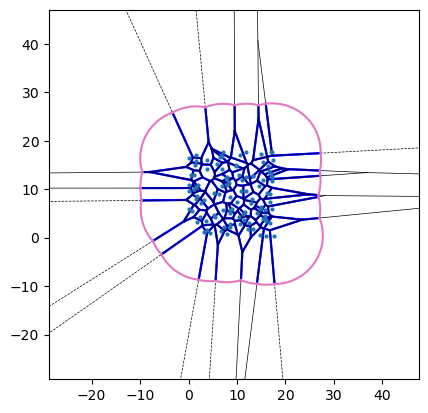

In [5]:
sim = FiniteVoronoiSimulator(pts, params)
sim.plot_2d()

In [6]:
pts_pbc, idx_pbc = tile_pbc_with_index(pts, radius, L)
sim.update_positions(pts_pbc)

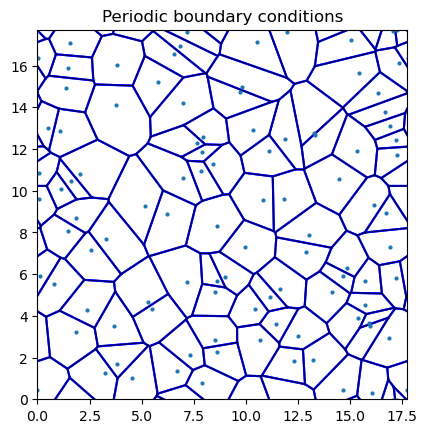

In [7]:
fig, ax = plt.subplots(dpi=100)
ax = sim.plot_2d()

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_title("Periodic boundary conditions")

plt.show()

In [8]:
# Initial relaxation
dt = 0.01
for _ in tqdm(range(1000)):
    diag = sim.build()
    pts += diag["forces"][:N] * dt
    pts = pts % L
    pts_pbc, idx_pbc = tile_pbc_with_index(pts, radius, L)
    sim.update_positions(pts_pbc)

  0%|          | 0/1000 [00:00<?, ?it/s]

(0.0, 17.72453850905516)

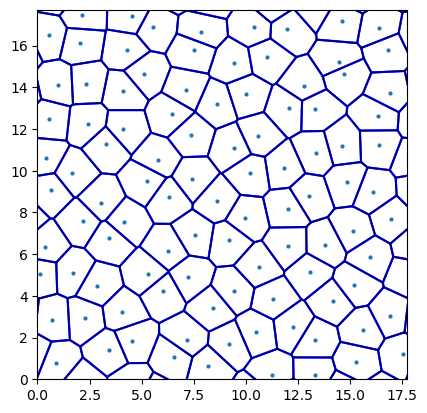

In [9]:
ax = sim.plot_2d()
ax.set_xlim(0, L)
ax.set_ylim(0, L)

In [10]:
base_colors = ["#9A9EC8", "#B69F80", "#728A75", "#A3B6BD"]
cell_colors = np.random.choice(base_colors, size=N)

In [11]:
def custom_plot_2d(pts: np.ndarray, cell_colors: np.ndarray, diag: dict, r: float, ax=None):
    """
    Custom plot function
    """
    if ax is None:
        ax = plt.gca()
    
    point_vertices_f_idx = diag["regions"]
    vertices_all = diag["vertices"]

    # Draw cell centers
    ax.plot(pts[:, 0], pts[:, 1], 'o', color='lightgray', markersize=2, zorder=3, clip_on=True)

    N = len(pts)

    # Draw each cell boundary
    for idx in range(N):
        vertices_f_idx = point_vertices_f_idx[idx].copy()

        vertices_f_idx.append(vertices_f_idx[0])
        boundary = vertices_all[vertices_f_idx]

        ax.plot(boundary[:, 0], boundary[:, 1], color="lightgray", lw=1., zorder=2)
        ax.fill(boundary[:, 0], boundary[:, 1], color=cell_colors[idx], lw=0, zorder=0)

    ax.set_aspect("equal")
    return ax


from matplotlib.collections import LineCollection, PolyCollection


def custom_plot_2d_fast(pts: np.ndarray, cell_colors: list, diag: dict, r: float, ax=None):
    """
    Faster custom plot function (vectorized version)
    
    The speedup is especially noticeable when plotting large-N systems and generating many frames for videos.
    """
    if ax is None:
      ax = plt.gca()
    
    point_vertices_f_idx = diag["regions"]
    vertices_all = diag["vertices"]
    
    # Cell centers
    ax.plot(pts[:, 0], pts[:, 1], 'o', color='lightgray', markersize=2, zorder=3, clip_on=True)
    
    # Per-cell closed polygons (ragged list; first vertex re-appended to close the stroke)
    polygons = [vertices_all[[*vs, vs[0]]] for vs in point_vertices_f_idx]
    
    # Fills (per-cell colors)
    ax.add_collection(PolyCollection(polygons, facecolors=cell_colors, linewidths=0, zorder=0))
    
    # Outlines (uniform)
    ax.add_collection(LineCollection(polygons, colors="lightgray", linewidths=1.0, zorder=2))
    
    ax.set_aspect("equal")
    return ax

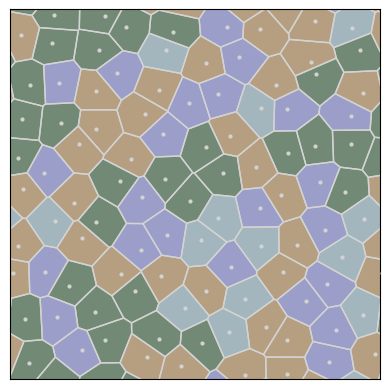

In [12]:
ax = custom_plot_2d_fast(pts_pbc, cell_colors[idx_pbc], diag, r=radius)

ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)
ax.set_facecolor('#474340')
ax.set_xlim(0, L)
ax.set_ylim(0, L)

plt.savefig("test2.png", bbox_inches='tight', dpi=300)

In [13]:
theta = 2. * np.pi * np.random.rand(N) - np.pi

In [14]:
steps = 15_000
va = 0.3
mu = 1.0
Dr = 0.3

for _ in tqdm(range(steps)):
    pts_pbc, idx_pbc = tile_pbc_with_index(pts, radius, L)

    sim.update_positions(pts_pbc)
    diag = sim.build()

    forces = diag['forces'][:N]
    
    vx = mu * forces[:, 0] + va * np.cos(theta)
    vy = mu * forces[:, 1] + va * np.sin(theta)
    theta0 = np.arctan2(vy, vx)

    if _ % 50 == 0:
    # Plot the first N cells
        fig, ax = plt.subplots()
        ax = custom_plot_2d_fast(pts_pbc, cell_colors[idx_pbc], diag, radius)
        ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)

        ax.set_xlim(0, L)
        ax.set_ylim(0, L)

        plt.savefig(f"frames/{_}.png", bbox_inches='tight', pad_inches=0.3, dpi=300)
        plt.close(fig)


    pts[:, 0] += vx * dt
    pts[:, 1] += vy * dt
    pts = pts % L

    # Gaussian white noise
    noise = np.sqrt(2 * Dr * dt) * np.random.randn(N)
    theta += noise


  0%|          | 0/15000 [00:00<?, ?it/s]

In [15]:
!python video_generate.py

Done!
